<a href="https://colab.research.google.com/github/ColinaAndres/Heart-Disease-Prediction/blob/main/notebooks/Regresion_Logistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports y Google Drive autenticacion

In [ ]:
import plotly.express as px
import plotly.figure_factory as ff
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

# Authenticate and create the PyDrive client
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

In [ ]:
id = '1QHrv5jOfyW6znzSvY8U4eGgLsAWa_Ln0'
downloaded = drive.CreateFile({'id': id})
downloaded.GetContentFile('heart_train.csv')

In [ ]:
id_test = '1ToTRlYQqwxhNn48T5JvIoEFxCxDmZRpR'
downloaded_test = drive.CreateFile({'id': id_test})
downloaded_test.GetContentFile('heart_test.csv')

# Carga DataSet

In [ ]:
heart_data = pd.read_csv('heart_train.csv',encoding='latin1')
test_data = pd.read_csv('heart_test.csv',encoding='latin1')
heart_data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,63,M,ATA,139,217,1,ST,128,Y,1.2,Flat,1
1,55,M,ATA,110,214,1,ST,180,N,0.4,Up,0
2,59,F,ASY,130,338,1,ST,130,Y,1.5,Flat,1
3,47,M,ASY,160,0,0,Normal,124,Y,0.0,Flat,1
4,50,M,ASY,145,0,1,Normal,139,Y,0.7,Flat,1


In [ ]:
test_data.head() # solo para corroborar que se subio bien

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,46,M,ASY,115,0,0,Normal,113,Y,1.5,Flat
1,58,M,NAP,132,224,0,LVH,173,N,3.2,Up
2,60,M,ASY,125,258,0,LVH,141,Y,2.8,Flat
3,49,M,NAP,120,188,0,Normal,139,N,2.0,Flat
4,39,F,NAP,138,220,0,Normal,152,N,0.0,Flat


# Matchine Learning

## Division

In [ ]:
x = heart_data.drop('HeartDisease', axis=1)
y = heart_data['HeartDisease']

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_validation, y_train, y_validation = train_test_split(x, y, test_size=0.2, random_state=4)

## Preprocesamiento

Hacemos un solo hot encoding a los set para cada categoria, es decir transformamos cada categoria de cada columna en su propia columna binaria. Ademas normalizamos las columnas numericas

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

original_cols_ordenr = x_train.columns.tolist()
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'FastingBS']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
    ]
)

x_train_final = preprocessor.fit_transform(x_train)
x_val_final = preprocessor.transform(x_validation)
test_data_final = preprocessor.transform(test_data)


todas las nuevas columnas se obtienen asi:

In [ ]:
num_features = num_cols
ohe = preprocessor.named_transformers_['cat']
cat_features = ohe.get_feature_names_out(cat_cols)
all_feature_names = np.concatenate([num_features, cat_features])

## Busqueda de Hiperparametros

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

In [ ]:
log_reg = LogisticRegression()

In [ ]:
params = [
    {'penalty': ['l2'],
     'C': [0.0001, 0.001, 0.01, 0.1, 1],
     'solver':['lbfgs', 'newton-cg','newton-cholesky', 'sag']},

    {'penalty': ['l1','l2'],
     'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
     'solver':['liblinear']},
]

In [ ]:
rs = RandomizedSearchCV(log_reg, param_distributions=params, n_iter=10, random_state=4, scoring='roc_auc')

In [ ]:
rs.fit(x_train_final, y_train)

RandomizedSearchCV(estimator=LogisticRegression(),
                   param_distributions=[{'C': [0.0001, 0.001, 0.01, 0.1, 1],
                                         'penalty': ['l2'],
                                         'solver': ['lbfgs', 'newton-cg',
                                                    'newton-cholesky', 'sag']},
                                        {'C': [0.0001, 0.001, 0.01, 0.1, 1, 10,
                                               100],
                                         'penalty': ['l1', 'l2'],
                                         'solver': ['liblinear']}],
                   random_state=4, scoring='roc_auc')

In [ ]:
rs.best_params_

{'solver': 'lbfgs', 'penalty': 'l2', 'C': 1}

In [ ]:
model = rs.best_estimator_

In [ ]:
model.fit(x_train_final, y_train)

LogisticRegression(C=1)

## Evaluacion del Modelo

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
y_pred = model.predict(x_val_final)
y_validation = y_validation.astype(int)

In [ ]:
cm = confusion_matrix(y_validation, y_pred)
cm

array([[56,  9],
       [13, 69]])

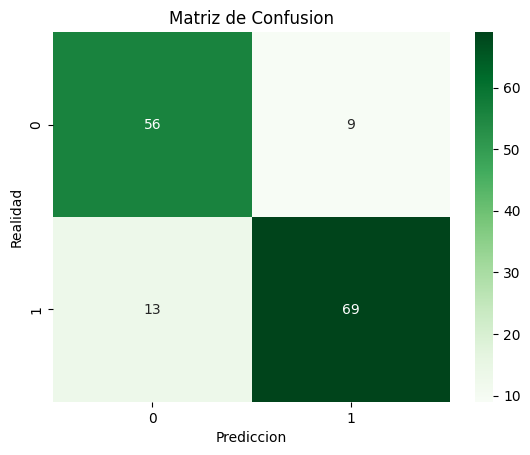

In [ ]:
sns.heatmap(cm, annot=True, cmap='Greens')
plt.title('Matriz de Confusion')
plt.xlabel('Prediccion')
plt.ylabel('Realidad')
plt.show()

In [ ]:
accuracy_score(y_validation, y_pred)

0.8503401360544217

In [ ]:
sensibility_score = cm[1][1] / sum(cm[1])
sensibility_score

np.float64(0.8414634146341463)

In [ ]:
from sklearn.metrics import roc_auc_score

In [ ]:
y_pred = y_pred.astype(str)
y_validation = y_validation.astype(str)
y_prob = model.predict_proba(x_val_final)[:, 1]
roc_auc_score(y_validation, y_prob)

np.float64(0.9163227016885553)

## Features mas importantes

In [ ]:
model.coef_[0]

array([ 0.03723477,  0.01270507, -0.43204079, -0.18807655,  0.27461692,
        0.31848904,  1.23251402, -1.61190196, -1.65099588, -1.34591626,
        0.00691758,  0.09443676,  0.81887242,  0.7980219 , -1.56555204])

In [ ]:
coef = model.coef_[0]

df_importances = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coef,
    'AbsImportance': np.abs(coef)
})

df_importances = df_importances.sort_values(by='AbsImportance', ascending=True)

fig = go.Figure(go.Bar(
    x=df_importances['AbsImportance'],
    y=df_importances['Feature'],
    orientation='h',
    marker=dict(
        color=df_importances['AbsImportance'],
        colorscale='inferno',
        showscale=True
    ),
))

fig.update_layout(
    title='Importancia de Features - Regresión Logística',
    title_font=dict(size=24, family='Arial', color='black'),
    xaxis=dict(
        title='Coeficientes (Importancia)',
        titlefont=dict(size=18),
        tickfont=dict(size=14)
    ),
    yaxis=dict(
        title='Features',
        titlefont=dict(size=18),
        tickfont=dict(size=14)
    ),
    margin=dict(l=200, r=50, t=70, b=50),
    showlegend=False
)

fig.show()


# Prediccion para la competencia

In [ ]:
prediccion = model.predict(test_data_final)
prediccion

array([1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 1, 1])

In [ ]:
submission = pd.DataFrame({'id': range(len(prediccion)), 'target': prediccion})
submission

,id,target
0,0,1
1,1,0
2,2,1
3,3,1
4,4,0
...,...,...
179,179,0
180,180,1
181,181,1
182,182,1


In [ ]:
submission.to_csv('submission_reg_log.csv', index=False)